In [1]:
import sys
print(sys.executable)

d:\Smart traffic vision\venv\Scripts\python.exe


In [2]:
from ultralytics import YOLO

In [3]:
model = YOLO("yolov8n.pt")

In [5]:
results = model.train(
    data=r"Cars Detection\data.yaml",
    epochs=5,
    imgsz=640,
    batch=16,
    project="runs",
    name="cars_detection"
)

Ultralytics 8.4.37  Python-3.11.9 torch-2.11.0+cpu CPU (Intel Core i5-1035G1 1.00GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Cars Detection\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cars_detection2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

In [6]:
from ultralytics import YOLO
import cv2
import os

In [7]:
model = YOLO(r"D:\Smart traffic vision\runs\detect\runs\cars_detection2\weights\best.pt")

In [8]:
input_video = r"videos\traffic.mp4"
output_video = r"videos\traffic_output.mp4"

In [9]:
cap = cv2.VideoCapture(input_video)

if not cap.isOpened():
    print("Error: Could not open video.")
else:
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video, fourcc, fps, (frame_width, frame_height))

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame)

        annotated_frame = results[0].plot()
        out.write(annotated_frame)

    cap.release()
    out.release()
    cv2.destroyAllWindows()

    print(f"Processed video saved at: {output_video}")


0: 384x640 3 Cars, 7 Trucks, 129.1ms
Speed: 160.9ms preprocess, 129.1ms inference, 5.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 Cars, 6 Trucks, 73.9ms
Speed: 3.5ms preprocess, 73.9ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 Cars, 9 Trucks, 78.9ms
Speed: 2.2ms preprocess, 78.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 Cars, 6 Trucks, 64.0ms
Speed: 3.1ms preprocess, 64.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 Cars, 5 Trucks, 61.8ms
Speed: 2.6ms preprocess, 61.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 Cars, 5 Trucks, 58.3ms
Speed: 2.5ms preprocess, 58.3ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 Cars, 5 Trucks, 73.2ms
Speed: 2.4ms preprocess, 73.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 Cars, 6 Trucks, 110.5ms
Speed: 5.7ms preproc

In [11]:
from ultralytics import YOLO
import cv2
from collections import Counter

model = YOLO(r"D:\Smart traffic vision\runs\detect\runs\cars_detection2\weights\best.pt")

input_video = r"videos\traffic.mp4"
output_video = r"videos\traffic_counted.mp4"

cap = cv2.VideoCapture(input_video)

if not cap.isOpened():
    print("Error: Could not open video.")
else:
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video, fourcc, fps, (frame_width, frame_height))

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, conf=0.5)
        annotated_frame = results[0].plot()

        counts = Counter()

        for box in results[0].boxes:
            cls_id = int(box.cls[0].item())
            class_name = model.names[cls_id]
            counts[class_name] += 1

        y = 30
        for vehicle_type, count in counts.items():
            text = f"{vehicle_type}: {count}"
            cv2.putText(
                annotated_frame,
                text,
                (20, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 255),
                2
            )
            y += 30

        out.write(annotated_frame)

    cap.release()
    out.release()
    cv2.destroyAllWindows()

    print(f"Processed video saved at: {output_video}")


0: 384x640 1 Truck, 79.0ms
Speed: 161.2ms preprocess, 79.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Truck, 83.5ms
Speed: 4.1ms preprocess, 83.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Truck, 78.8ms
Speed: 3.4ms preprocess, 78.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Truck, 64.2ms
Speed: 2.5ms preprocess, 64.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Car, 1 Truck, 76.3ms
Speed: 2.2ms preprocess, 76.3ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Car, 1 Truck, 72.9ms
Speed: 2.2ms preprocess, 72.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Truck, 86.4ms
Speed: 2.5ms preprocess, 86.4ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Truck, 97.3ms
Speed: 5.0ms preprocess, 97.3ms inference, 2.1ms postprocess per image at shape (

In [13]:
! pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB 991.0 kB/s eta 0:00:10
   -- ------------------------------------- 0.5/9.9 MB 6.3 MB/s eta 0:00:02
   ----- ---------------------------------- 1.4/9.9 MB 11.3 MB/s eta 0:00:01
   -------- ------------------------------- 2.2/9.9 MB 12.6 MB/s eta 0:00:01
   ------------ --------------------------- 3.1/9.9 MB 14.4 MB/s eta 0:00:01
   ---------------- ----------------------- 4.0/9.9 MB 15.0 MB/s eta 0:00:01
   ------------------- -------------------- 4.8/9.9 MB 16.3 MB/s eta 0:00:01
   ----------------------- ---------------- 5.8/9.9 MB 17.0 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.9 MB 17.4 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 17.3 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.9 MB 17.5 MB/s eta 0:00:01
   ---------------------------------------  9.9/9.9 MB 18.6 MB/s eta 0:00:01
   ----


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from ultralytics import YOLO
import cv2
import pandas as pd
from collections import Counter
import os

model = YOLO(r"D:\Smart traffic vision\runs\detect\runs\cars_detection2\weights\best.pt")

input_video = r"videos\traffic.mp4"
output_video = r"videos\traffic_analysis.mp4"
csv_output = r"videos\traffic_class_analysis.csv"

os.makedirs("videos", exist_ok=True)

cap = cv2.VideoCapture(input_video)

if not cap.isOpened():
    print("Error: Could not open video.")
else:
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video, fourcc, fps, (frame_width, frame_height))

    records = []
    frame_number = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_number += 1

        results = model(frame, conf=0.5)
        annotated_frame = results[0].plot()

        counts = Counter()

        for box in results[0].boxes:
            cls_id = int(box.cls[0].item())
            class_name = model.names[cls_id]
            counts[class_name] += 1

        # write counts on video frame
        y = 30
        for vehicle_type, count in sorted(counts.items()):
            text = f"{vehicle_type}: {count}"
            cv2.putText(
                annotated_frame,
                text,
                (20, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 255),
                2
            )
            y += 30

        out.write(annotated_frame)

        # save per-frame counts
        row = {"frame": frame_number}
        for class_name in model.names.values():
            row[class_name] = counts.get(class_name, 0)
        records.append(row)

    cap.release()
    out.release()
    cv2.destroyAllWindows()

    df = pd.DataFrame(records)
    df.to_csv(csv_output, index=False)

    print(f"Processed video saved at: {output_video}")
    print(f"Class-wise analysis CSV saved at: {csv_output}")


0: 384x640 1 Truck, 59.7ms
Speed: 142.8ms preprocess, 59.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Truck, 60.3ms
Speed: 2.0ms preprocess, 60.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Truck, 55.4ms
Speed: 2.2ms preprocess, 55.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Truck, 70.0ms
Speed: 2.5ms preprocess, 70.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Car, 1 Truck, 58.5ms
Speed: 2.5ms preprocess, 58.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Car, 1 Truck, 58.6ms
Speed: 2.1ms preprocess, 58.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Truck, 61.3ms
Speed: 2.2ms preprocess, 61.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Truck, 73.1ms
Speed: 3.1ms preprocess, 73.1ms inference, 1.2ms postprocess per image at shape (

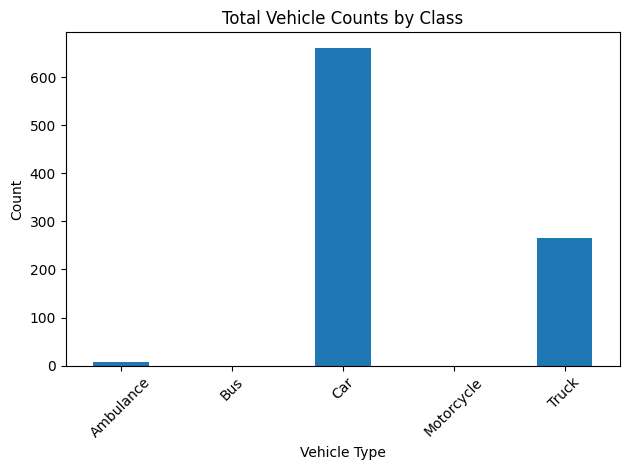

In [18]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"videos\traffic_class_analysis.csv")

summary = df.drop(columns=["frame"]).sum()

plt.figure()
summary.plot(kind='bar')
plt.title("Total Vehicle Counts by Class")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()